# 03 — BigQuery ML Analysis

After dbt has transformed the data into `opp_budget.fct_budget_execution`, run ML experiments:

1. **Linear regression**: predict next-year budget allocation
2. **K-means clustering**: group incisos by spending patterns

## Setup

In [1]:
!pip install -q google-cloud-bigquery==3.27.0 db-dtypes==1.3.1 pyarrow==18.1.0 matplotlib==3.9.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.1/240.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 25.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.38.0 requires db-dtypes>=1.4.2, but you have db-dtypes 1.3.1 which is incompatible.
bigframes 2.38.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.36.0, but you have google-cloud-bigquery 3.27.0 which is incompatible.


In [2]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "fabled-imagery-488015-p6"
client = bigquery.Client(project=PROJECT_ID)

print(f"Connected to BigQuery project: {PROJECT_ID}")

Connected to BigQuery project: fabled-imagery-488015-p6


## Preview Data

In [3]:
query = """
SELECT *
FROM `opp_budget.fct_budget_execution`
ORDER BY fiscal_year DESC, total_credito_vigente DESC
LIMIT 20
"""
df = client.query(query).to_dataframe()
print(f"Rows: {len(df)}, Columns: {list(df.columns)}")
df.head(20)

Rows: 20, Columns: ['execution_id', 'fiscal_year', 'inciso', 'denominacion_inciso', 'categoria', 'total_credito_vigente', 'total_ejecucion', 'avg_execution_rate_pct', 'avg_credito_yoy_pct_change', 'record_count', 'source_count']


,execution_id,fiscal_year,inciso,denominacion_inciso,categoria,total_credito_vigente,total_ejecucion,avg_execution_rate_pct,avg_credito_yoy_pct_change,record_count,source_count
0,a07a0239364ca6ba0c2315f26eddc3de,2029,14,Ministerio de Vivienda y Ordenamiento Territorial,Obras Civiles - Viviendas,120405133.0,NaN,NaN,318.55,1,1
1,a52d21e6f077d0ce3ff1728fda59d014,2029,14,Ministerio de Vivienda y Ordenamiento Territorial,Transferencia de Capital a Si,25899788.0,NaN,NaN,83.41,1,1
2,255b8a12391ac9a5eba5c01578b6f7eb,2029,10,Ministerio de Transporte y Obras Públicas,Civiles-Infraestructura Transporte Terrestre,16654155.0,NaN,NaN,36.26,1,1
3,3fa2f72731a6b48f13b4909363d4a183,2028,14,Ministerio de Vivienda y Ordenamiento Territorial,Obras Civiles - Viviendas,28767416.0,NaN,NaN,29.87,1,1
4,96fc50c4d2839ca472a4e6d071bc240c,2028,14,Ministerio de Vivienda y Ordenamiento Territorial,Transferencia de Capital a Si,14121500.0,NaN,NaN,-34.21,1,1
5,3b72e5d8bdbf3306a2f2b49fd46d8468,2028,10,Ministerio de Transporte y Obras Públicas,Civiles-Infraestructura Transporte Terrestre,12222265.0,NaN,NaN,0.85,1,1
6,42cda4bf627b8ec2b578e202cb896d8a,2027,14,Ministerio de Vivienda y Ordenamiento Territorial,Obras Civiles - Viviendas,22150320.0,NaN,NaN,-63.36,1,1
7,d7dca74b3c1846daee298c856fdcce19,2027,14,Ministerio de Vivienda y Ordenamiento Territorial,Transferencia de Capital a Si,21464524.0,NaN,NaN,88.98,1,1
8,6b665cbbb9be19002761103aa544514b,2027,10,Ministerio de Transporte y Obras Públicas,Civiles-Infraestructura Transporte Terrestre,12119800.0,NaN,NaN,11.97,1,1
9,c206ea0fc3a25e49a69e35ddfcc583f8,2027,10,Ministerio de Transporte y Obras Públicas,Obras Civiles-Infraestructura Transporte Terre...,2902840.0,NaN,NaN,-97.43,1,1


In [4]:
summary = client.query("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT fiscal_year) AS distinct_years,
    COUNT(DISTINCT inciso) AS distinct_incisos,
    COUNT(DISTINCT categoria) AS distinct_categorias,
    MIN(fiscal_year) AS min_year,
    MAX(fiscal_year) AS max_year,
    SUM(total_credito_vigente) AS total_budget,
    SUM(total_ejecucion) AS total_ejecucion
FROM `opp_budget.fct_budget_execution`
""").to_dataframe()
summary

,total_rows,distinct_years,distinct_incisos,distinct_categorias,min_year,max_year,total_budget,total_ejecucion
0,6024,24,36,1615,2005,2029,8.847999e+12,4.626547e+12


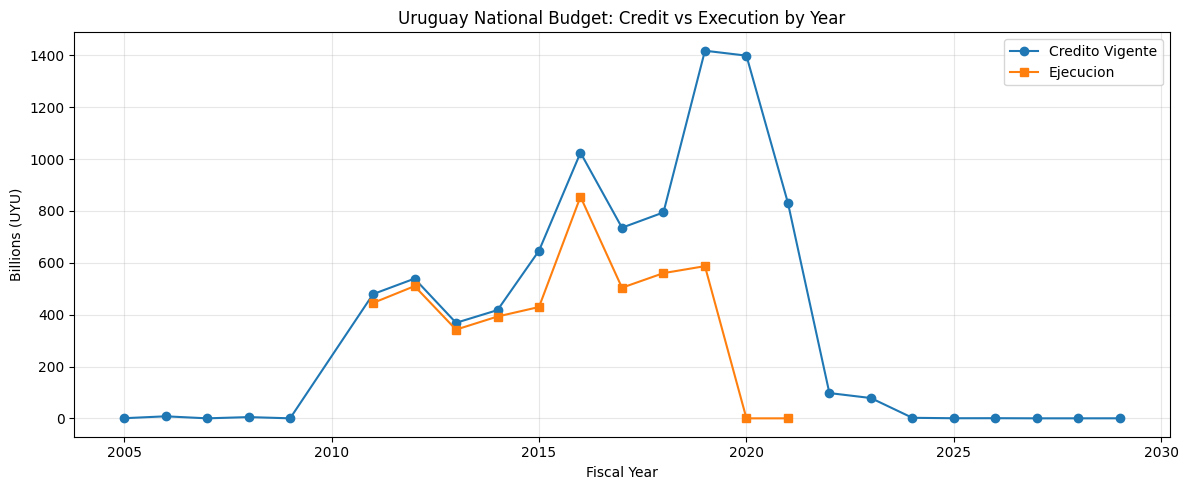

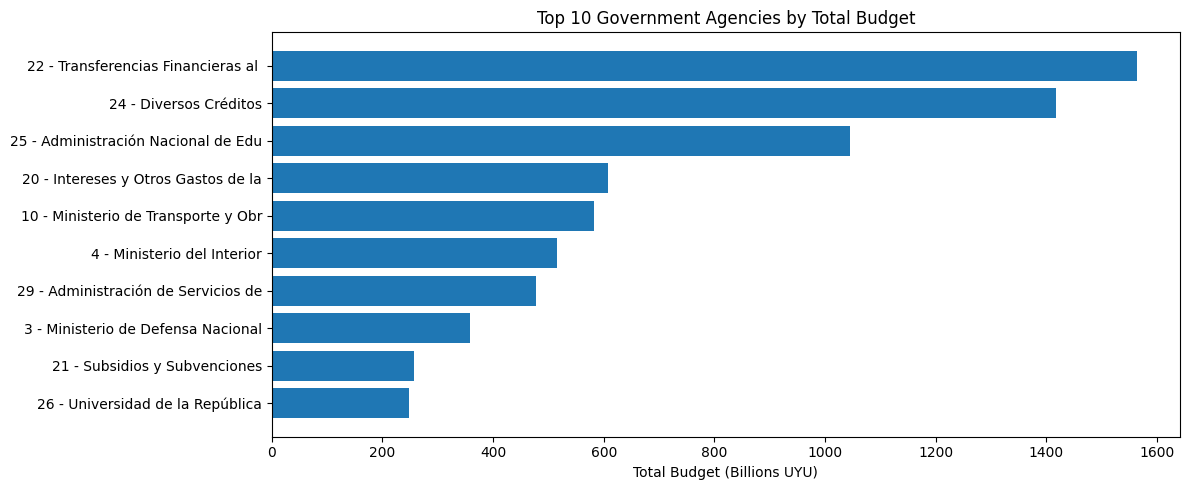

In [5]:
import matplotlib.pyplot as plt

# Budget evolution by year
yearly = client.query("""
SELECT
    fiscal_year,
    SUM(total_credito_vigente) AS credito,
    SUM(total_ejecucion) AS ejecucion
FROM `opp_budget.fct_budget_execution`
GROUP BY fiscal_year
ORDER BY fiscal_year
""").to_dataframe()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly["fiscal_year"], yearly["credito"] / 1e9, marker="o", label="Credito Vigente")
ax.plot(yearly["fiscal_year"], yearly["ejecucion"] / 1e9, marker="s", label="Ejecucion")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Billions (UYU)")
ax.set_title("Uruguay National Budget: Credit vs Execution by Year")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Top 10 incisos by total budget
top_incisos = client.query("""
SELECT
    inciso,
    denominacion_inciso,
    SUM(total_credito_vigente) AS total_budget
FROM `opp_budget.fct_budget_execution`
GROUP BY inciso, denominacion_inciso
ORDER BY total_budget DESC
LIMIT 10
""").to_dataframe()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    [f"{r.inciso} - {r.denominacion_inciso[:30]}" for _, r in top_incisos.iterrows()],
    top_incisos["total_budget"] / 1e9,
)
ax.set_xlabel("Total Budget (Billions UYU)")
ax.set_title("Top 10 Government Agencies by Total Budget")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Experiment 1: Linear Regression — Budget Forecasting

In [6]:
# Create the model
create_model_sql = """
CREATE OR REPLACE MODEL `opp_budget.budget_forecast`
OPTIONS(
    model_type='LINEAR_REG',
    input_label_cols=['total_credito_vigente']
) AS
SELECT
    fiscal_year,
    inciso,
    COALESCE(avg_credito_yoy_pct_change, 0) AS yoy_change,
    COALESCE(avg_execution_rate_pct, 0) AS exec_rate,
    total_credito_vigente
FROM `opp_budget.fct_budget_execution`
WHERE total_credito_vigente IS NOT NULL
  AND total_credito_vigente > 0
"""

print("Training linear regression model...")
client.query(create_model_sql).result()
print("Model created: opp_budget.budget_forecast")

Training linear regression model...
Model created: opp_budget.budget_forecast


In [7]:
# Evaluate
eval_df = client.query("""
SELECT * FROM ML.EVALUATE(MODEL `opp_budget.budget_forecast`)
""").to_dataframe()
print("Model evaluation metrics:")
eval_df

Model evaluation metrics:


,mean_absolute_error,mean_squared_error,mean_squared_log_error,median_absolute_error,r2_score,explained_variance
0,2.296611e+09,9.407879e+19,52.535041,1.179185e+09,0.017244,0.017363


In [8]:
# Predict next year's budget for top incisos
predict_df = client.query("""
SELECT
    p.inciso,
    f.denominacion_inciso,
    p.predicted_total_credito_vigente,
    p.total_credito_vigente AS actual
FROM ML.PREDICT(MODEL `opp_budget.budget_forecast`,
    (SELECT
        fiscal_year + 1 AS fiscal_year,
        inciso,
        COALESCE(avg_credito_yoy_pct_change, 0) AS yoy_change,
        COALESCE(avg_execution_rate_pct, 0) AS exec_rate,
        total_credito_vigente
    FROM `opp_budget.fct_budget_execution`
    WHERE fiscal_year = (SELECT MAX(fiscal_year) FROM `opp_budget.fct_budget_execution`)
      AND total_credito_vigente IS NOT NULL)
) p
LEFT JOIN (
    SELECT DISTINCT inciso, denominacion_inciso
    FROM `opp_budget.fct_budget_execution`
) f ON p.inciso = f.inciso
ORDER BY p.predicted_total_credito_vigente DESC
LIMIT 15
""").to_dataframe()
print("Budget predictions for next fiscal year (top 15):")
predict_df

Budget predictions for next fiscal year (top 15):


,inciso,denominacion_inciso,predicted_total_credito_vigente,actual
0,14,Ministerio de Vivienda y Ordenamiento Territorial,7.451899e+07,120405133.0
1,14,"Mtrio. de Vivienda,Ordenamiento Territorial y ...",7.451899e+07,120405133.0
2,14,Ministerio de Vivienda y Ordenamiento Territorial,7.451884e+07,25899788.0
3,14,"Mtrio. de Vivienda,Ordenamiento Territorial y ...",7.451884e+07,25899788.0
4,10,Ministerio de Transporte y Obras Públicas,-3.779628e+08,16654155.0


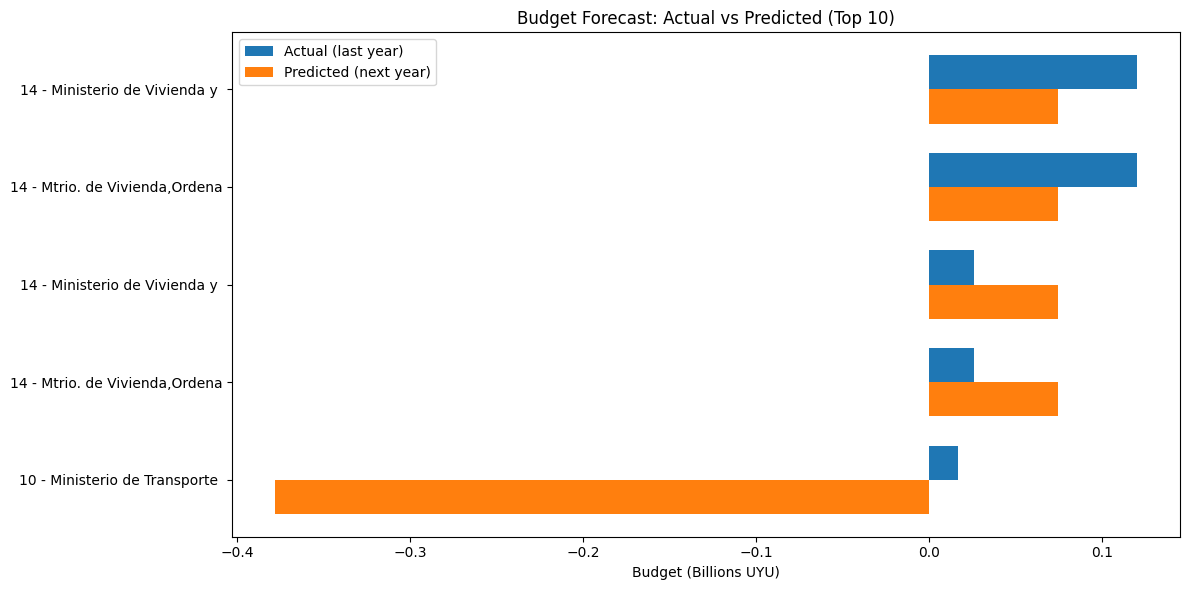

In [9]:
# Visualize predictions vs actual
fig, ax = plt.subplots(figsize=(12, 6))
labels = [f"{r.inciso} - {str(r.denominacion_inciso)[:25]}" for _, r in predict_df.head(10).iterrows()]
x = range(len(labels))
width = 0.35
ax.barh([i - width/2 for i in x], predict_df.head(10)["actual"] / 1e9, width, label="Actual (last year)")
ax.barh([i + width/2 for i in x], predict_df.head(10)["predicted_total_credito_vigente"] / 1e9, width, label="Predicted (next year)")
ax.set_yticks(list(x))
ax.set_yticklabels(labels)
ax.set_xlabel("Budget (Billions UYU)")
ax.set_title("Budget Forecast: Actual vs Predicted (Top 10)")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Experiment 2: K-Means Clustering — Spending Patterns

In [10]:
# Create clustering model
kmeans_sql = """
CREATE OR REPLACE MODEL `opp_budget.inciso_clusters`
OPTIONS(
    model_type='KMEANS',
    num_clusters=5
) AS
SELECT
    inciso,
    AVG(total_credito_vigente) AS avg_budget,
    AVG(total_ejecucion) AS avg_execution,
    AVG(COALESCE(avg_execution_rate_pct, 0)) AS avg_exec_rate,
    AVG(COALESCE(avg_credito_yoy_pct_change, 0)) AS avg_yoy_change,
    COUNT(DISTINCT fiscal_year) AS years_active
FROM `opp_budget.fct_budget_execution`
WHERE total_credito_vigente IS NOT NULL
GROUP BY inciso
"""

print("Training K-Means clustering model...")
client.query(kmeans_sql).result()
print("Model created: opp_budget.inciso_clusters")

Training K-Means clustering model...
Model created: opp_budget.inciso_clusters


In [11]:
# View cluster assignments with agency names
clusters_df = client.query("""
SELECT
    p.CENTROID_ID,
    p.inciso,
    f.denominacion_inciso,
    p.avg_budget,
    p.avg_execution,
    p.avg_exec_rate,
    p.avg_yoy_change
FROM ML.PREDICT(MODEL `opp_budget.inciso_clusters`,
    (SELECT
        inciso,
        AVG(total_credito_vigente) AS avg_budget,
        AVG(total_ejecucion) AS avg_execution,
        AVG(COALESCE(avg_execution_rate_pct, 0)) AS avg_exec_rate,
        AVG(COALESCE(avg_credito_yoy_pct_change, 0)) AS avg_yoy_change,
        COUNT(DISTINCT fiscal_year) AS years_active
    FROM `opp_budget.fct_budget_execution`
    WHERE total_credito_vigente IS NOT NULL
    GROUP BY inciso)
) p
LEFT JOIN (
    SELECT DISTINCT inciso, denominacion_inciso
    FROM `opp_budget.fct_budget_execution`
) f ON p.inciso = f.inciso
ORDER BY CENTROID_ID, avg_budget DESC
""").to_dataframe()

print("Cluster assignments:")
clusters_df

Cluster assignments:


,CENTROID_ID,inciso,denominacion_inciso,avg_budget,avg_execution,avg_exec_rate,avg_yoy_change
0,1,25,Administración Nacional de Educación Pública,6.415426e+09,1.641441e+10,13.269652,3.181842e+08
1,2,35,Instituto Nacional de Inclusion Social Adolesc...,6.482657e+08,2.331093e+08,0.421068,1.039582e+06
2,2,35,Instituto Nacional de Inclusión Social Adolesc...,6.482657e+08,2.331093e+08,0.421068,1.039582e+06
3,2,33,Fiscalia General de la Nación,1.773569e+08,2.320770e+08,27.730577,2.532128e+06
4,2,33,Fiscalía General de la Nación,1.773569e+08,2.320770e+08,27.730577,2.532128e+06
5,2,31,Universidad Tecnológica del Uruguay,1.732503e+08,1.496031e+08,29.074441,5.177380e+03
6,2,32,Instituto Uruguayo de Meteorología,4.724999e+07,5.323332e+07,14.800425,1.180623e+04
7,2,36,Ministerio de Ambiente,4.423816e+07,0.000000e+00,0.000000,1.353802e+06
8,2,30,Equipamiento y Mobiliario Reloj de asistencia,1.223355e+07,NaN,0.000000,2.888650e+02
9,2,30,Administración de los Servicios de Salud del E...,1.223355e+07,NaN,0.000000,2.888650e+02


In [12]:
# Cluster summary with agency names
print("Cluster profiles:\n")
for cid in sorted(clusters_df["CENTROID_ID"].unique()):
    group = clusters_df[clusters_df["CENTROID_ID"] == cid]
    names = [f"{r.inciso}-{str(r.denominacion_inciso)[:30]}" for _, r in group.iterrows()]
    print(f"  Cluster {cid}: {len(group)} incisos")
    print(f"    Avg budget:     {group['avg_budget'].mean():,.0f}")
    print(f"    Avg exec rate:  {group['avg_exec_rate'].mean():.1f}%")
    print(f"    Avg YoY change: {group['avg_yoy_change'].mean():.1f}%")
    print(f"    Agencies:       {', '.join(names[:5])}")
    if len(names) > 5:
        print(f"                    ... and {len(names) - 5} more")
    print()

Cluster profiles:

  Cluster 1: 1 incisos
    Avg budget:     6,415,425,627
    Avg exec rate:  13.3%
    Avg YoY change: 318184214.2%
    Agencies:       25-Administración Nacional de Edu

  Cluster 2: 23 incisos
    Avg budget:     89,666,948
    Avg exec rate:  7.5%
    Avg YoY change: 371514.6%
    Agencies:       35-Instituto Nacional de Inclusio, 35-Instituto Nacional de Inclusió, 33-Fiscalia General de la Nación, 33-Fiscalía General de la Nación, 31-Universidad Tecnológica del Ur
                    ... and 18 more

  Cluster 3: 10 incisos
    Avg budget:     1,645,816,721
    Avg exec rate:  988.7%
    Avg YoY change: 336616.3%
    Agencies:       29-Administración de Servicios de, 23-Partidas a Reaplicar, 21-Subsidios y Subvenciones, 27-Instituto del Niño y Adolescen, 26-Universidad de la República
                    ... and 5 more

  Cluster 4: 5 incisos
    Avg budget:     24,794,980,442
    Avg exec rate:  161792.9%
    Avg YoY change: 2995662.8%
    Agencies:       22-Tra

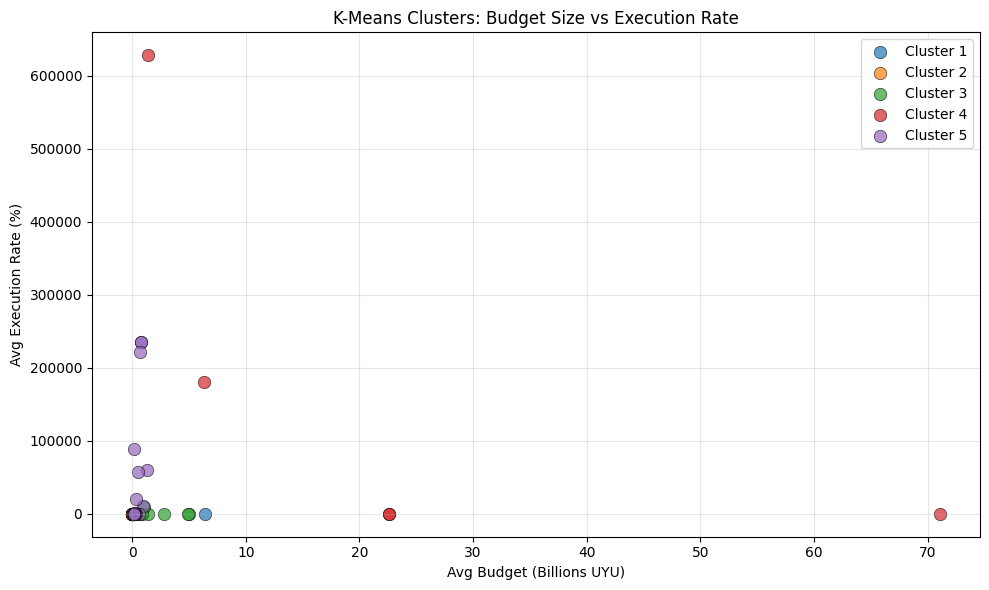

In [13]:
# Scatter plot of clusters: avg budget vs exec rate
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
for cid in sorted(clusters_df["CENTROID_ID"].unique()):
    group = clusters_df[clusters_df["CENTROID_ID"] == cid]
    ax.scatter(
        group["avg_budget"] / 1e9,
        group["avg_exec_rate"],
        c=colors[cid - 1] if cid <= len(colors) else "gray",
        label=f"Cluster {cid}",
        s=80, alpha=0.7, edgecolors="black", linewidth=0.5,
    )
ax.set_xlabel("Avg Budget (Billions UYU)")
ax.set_ylabel("Avg Execution Rate (%)")
ax.set_title("K-Means Clusters: Budget Size vs Execution Rate")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
print("BQML analysis complete.")
print("Models created:")
print("  - opp_budget.budget_forecast  (LINEAR_REG)")
print("  - opp_budget.inciso_clusters  (KMEANS)")

BQML analysis complete.
Models created:
  - opp_budget.budget_forecast  (LINEAR_REG)
  - opp_budget.inciso_clusters  (KMEANS)
